# Raw Coverage & Quality Dashboard

이 노트북은 **layer에서 실제로 사용되는 raw 데이터**가 서울 공간을 얼마나 잘 커버하는지 확인한다.

확인 질문:

- raw 데이터가 서울 전체/자치구별로 고르게 분포하는가?
- 좌표 결측치가 많은 raw는 무엇인가?
- 도보 네트워크는 자치구별로 얼마나 촘촘한가?
- API/OSM 데이터는 어떤 컬럼을 수집하며, 최신성/신뢰성을 어떻게 점검할 수 있는가?

## 1. 분석 대상 raw

layer에 실제 사용되는 raw를 우선 대상으로 본다. `서울시 자치구별 도보 네트워크 공간정보.csv`는 score layer raw는 아니지만, 경로 탐색 기반 데이터라 별도 섹션에서 분석한다.

In [45]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

ROOT = Path.cwd()
if ROOT.name == "raw":
    ROOT = ROOT.parents[1]
elif ROOT.name == "analysis":
    ROOT = ROOT.parent

# Windows matplotlib Korean font setting
font_path = Path("C:/Windows/Fonts/malgun.ttf")
if font_path.exists():
    font_name = fm.FontProperties(fname=str(font_path)).get_name()
    plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

RAW_DIR = ROOT / "src" / "data" / "raw"
FIGURE_DIR = ROOT / "analysis" / "figures" / "raw"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR

WindowsPath('c:/Users/82102/Desktop/seoul-walk-platform/src/data/raw')

In [46]:
active_raw_meta = pd.DataFrame([
    {
        "raw_name": "전국어린이보호구역표준데이터.csv",
        "source_type": "CSV",
        "raw_table": "csv_raw",
        "collector": "ChildCollector",
        "used_for_layer": "child_layer",
        "score": "child_score",
        "lat_col": "위도",
        "lon_col": "경도",
        "gu_col_or_address_col": "소재지지번주소",
    },
    {
        "raw_name": "전국스마트가로등표준데이터.csv",
        "source_type": "CSV",
        "raw_table": "csv_raw",
        "collector": "SafetyCollector",
        "used_for_layer": "safety_layer",
        "score": "safety_score",
        "lat_col": "위도",
        "lon_col": "경도",
        "gu_col_or_address_col": "시군구명",
    },
    {
        "raw_name": "서울시CCTV정보.xlsx",
        "source_type": "XLSX",
        "raw_table": "csv_raw",
        "collector": "SafetyCollector",
        "used_for_layer": "safety_layer",
        "score": "safety_score",
        "lat_col": "WGS84위도",
        "lon_col": "WGS84경도",
        "gu_col_or_address_col": "소재지지번주소",
    },
    {
        "raw_name": "어린이놀이시설 API",
        "source_type": "Public API",
        "raw_table": "public_raw",
        "collector": "ChildCollector",
        "used_for_layer": "child_layer",
        "score": "child_score",
        "lat_col": "latCrtsVl -> lat",
        "lon_col": "lotCrtsVl -> lon",
        "gu_col_or_address_col": "ronaAddr -> address",
    },
    {
        "raw_name": "보행자 교통사고 다발지점 API",
        "source_type": "Public API",
        "raw_table": "public_raw",
        "collector": "SafetyCollector.update_accident",
        "used_for_layer": "safety_layer",
        "score": "safety_score",
        "lat_col": "la",
        "lon_col": "lo",
        "gu_col_or_address_col": "sido_sgg_nm",
    },
    {
        "raw_name": "OSM 녹지 태그 데이터",
        "source_type": "OSM",
        "raw_table": "osm_raw",
        "collector": "NatureCollector",
        "used_for_layer": "nature_layer",
        "score": "nature_score",
        "lat_col": "geometry centroid",
        "lon_col": "geometry centroid",
        "gu_col_or_address_col": "spatial join 필요",
    },
    {
        "raw_name": "TourAPI 관광지/문화시설 API",
        "source_type": "Public API",
        "raw_table": "public_raw",
        "collector": "LandmarkCollector",
        "used_for_layer": "landmark_layer",
        "score": "landmark_score",
        "lat_col": "mapy -> lat",
        "lon_col": "mapx -> lon",
        "gu_col_or_address_col": "addr1 -> address",
    },
    {
        "raw_name": "전국실외운동기구설치정보 API",
        "source_type": "Public API",
        "raw_table": "public_raw",
        "collector": "RunningCourseCollector.update_outdoor_exercise",
        "used_for_layer": "running_layer",
        "score": "running_score",
        "lat_col": "lat",
        "lon_col": "lot",
        "gu_col_or_address_col": "ctpvNm / lctnLotnoAddr",
    },
])

active_raw_meta

,raw_name,source_type,raw_table,collector,used_for_layer,score,lat_col,lon_col,gu_col_or_address_col
0,전국어린이보호구역표준데이터.csv,CSV,csv_raw,ChildCollector,child_layer,child_score,위도,경도,소재지지번주소
1,전국스마트가로등표준데이터.csv,CSV,csv_raw,SafetyCollector,safety_layer,safety_score,위도,경도,시군구명
2,서울시CCTV정보.xlsx,XLSX,csv_raw,SafetyCollector,safety_layer,safety_score,WGS84위도,WGS84경도,소재지지번주소
3,어린이놀이시설 API,Public API,public_raw,ChildCollector,child_layer,child_score,latCrtsVl -> lat,lotCrtsVl -> lon,ronaAddr -> address
4,보행자 교통사고 다발지점 API,Public API,public_raw,SafetyCollector.update_accident,safety_layer,safety_score,la,lo,sido_sgg_nm
5,OSM 녹지 태그 데이터,OSM,osm_raw,NatureCollector,nature_layer,nature_score,geometry centroid,geometry centroid,spatial join 필요
6,TourAPI 관광지/문화시설 API,Public API,public_raw,LandmarkCollector,landmark_layer,landmark_score,mapy -> lat,mapx -> lon,addr1 -> address
7,전국실외운동기구설치정보 API,Public API,public_raw,RunningCourseCollector.update_outdoor_exercise,running_layer,running_score,lat,lot,ctpvNm / lctnLotnoAddr


## 2. 파일 기반 raw 품질 요약

CSV/XLSX는 로컬 파일을 직접 읽어 row 수, 컬럼 수, 컬럼 이름, 좌표 결측치, 서울/자치구 구분 가능 여부를 먼저 확인한다.

컬럼 이름까지 확인해야 이 raw 데이터가 실제로 무엇을 설명하는 데이터인지 말할 수 있다.

서울을 대략 감싸는 임시 사각형 필터 
서울 위도 대략: 37.4 ~ 37.7
서울 경도 대략: 126.7 ~ 127.2
북위 37.5665°,동경 126.9780° = 시청 기준 

bbox 필터는 서울 데이터 1차 후보를 추리는 임시 필터이며,
최종 서울 여부 판단은 서울 행정구역 polygon 기반 spatial join으로 검증해야 한다.

In [47]:
def read_csv_korean(path: Path, **kwargs) -> pd.DataFrame:
    for encoding in ("cp949", "utf-8-sig", "utf-8"):
        try:
            return pd.read_csv(path, encoding=encoding, **kwargs)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, **kwargs)


SEOUL_BBOX = {
    "lat_min": 37.40,
    "lat_max": 37.72,
    "lon_min": 126.75,
    "lon_max": 127.22,
}


SEOUL_GU = {
    "강남구", "강동구", "강북구", "강서구", "관악구",
    "광진구", "구로구", "금천구", "노원구", "도봉구",
    "동대문구", "동작구", "마포구", "서대문구", "서초구",
    "성동구", "성북구", "송파구", "양천구", "영등포구",
    "용산구", "은평구", "종로구", "중구", "중랑구",
}


def ensure_figure_dir():
    global FIGURE_DIR
    root = globals().get("ROOT", Path.cwd())
    if root.name == "raw":
        root = root.parents[1]
    elif root.name == "analysis":
        root = root.parent
    FIGURE_DIR = root / "analysis" / "figures" / "raw"
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    return FIGURE_DIR


def extract_gu(value):
    if pd.isna(value):
        return None
    match = re.search(r"([가-힣]+구)", str(value))
    return match.group(1) if match else None


def extract_seoul_gu_from_row(row, candidate_cols):
    for col in candidate_cols:
        if col not in row.index:
            continue
        gu = extract_gu(row[col])
        if gu in SEOUL_GU:
            return gu
    return None


def build_seoul_mask(df, city_cols=None, address_cols=None, lat_col=None, lon_col=None):
    """서울 데이터만 분리하기 위한 필터.

    1순위: 시도명/주소 컬럼에 서울 포함 여부
    2순위: 좌표가 서울 bbox 안에 있는지 여부
    """
    mask = pd.Series(False, index=df.index)

    for col in city_cols or []:
        if col in df.columns:
            mask = mask | df[col].astype(str).str.contains("서울", na=False)

    for col in address_cols or []:
        if col in df.columns:
            mask = mask | df[col].astype(str).str.contains("서울", na=False)

    if lat_col in df.columns and lon_col in df.columns:
        lat = pd.to_numeric(df[lat_col], errors="coerce")
        lon = pd.to_numeric(df[lon_col], errors="coerce")
        coord_mask = lat.between(SEOUL_BBOX["lat_min"], SEOUL_BBOX["lat_max"]) & lon.between(SEOUL_BBOX["lon_min"], SEOUL_BBOX["lon_max"])
        mask = mask | coord_mask.fillna(False)

    return mask


def summarize_point_raw(name, df, lat_col, lon_col, gu_source_col=None):
    lat = pd.to_numeric(df[lat_col], errors="coerce") if lat_col in df.columns else pd.Series(dtype=float)
    lon = pd.to_numeric(df[lon_col], errors="coerce") if lon_col in df.columns else pd.Series(dtype=float)
    coord_missing = lat.isna() | lon.isna()
    gu = df[gu_source_col].map(extract_gu) if gu_source_col and gu_source_col in df.columns else pd.Series([None] * len(df))
    return {
        "raw_name": name,
        "rows": len(df),
        "columns": len(df.columns),
        "missing_coord_rows": int(coord_missing.sum()),
        "missing_coord_rate": round(float(coord_missing.mean()), 4) if len(df) else 0,
        "gu_detected_rows": int(gu.notna().sum()),
        "gu_detected_rate": round(float(gu.notna().mean()), 4) if len(df) else 0,
    }


file_raw_configs = [
    {
        "name": "전국어린이보호구역표준데이터.csv",
        "path": RAW_DIR / "전국어린이보호구역표준데이터.csv",
        "kind": "csv",
        "lat_col": "위도",
        "lon_col": "경도",
        "gu_col": "소재지지번주소",
        "city_cols": [],
        "address_cols": ["소재지도로명주소", "소재지지번주소"],
    },
    {
        "name": "전국스마트가로등표준데이터.csv",
        "path": RAW_DIR / "전국스마트가로등표준데이터.csv",
        "kind": "csv",
        "lat_col": "위도",
        "lon_col": "경도",
        "gu_col": "시군구명",
        "city_cols": ["시도명"],
        "address_cols": ["소재지도로명주소", "소재지지번주소"],
    },
    {
        "name": "서울시CCTV정보.xlsx",
        "path": RAW_DIR / "서울시CCTV정보.xlsx",
        "kind": "xlsx",
        "lat_col": "WGS84위도",
        "lon_col": "WGS84경도",
        "gu_col": "소재지지번주소",
        "city_cols": [],
        "address_cols": ["소재지지번주소"],
    },
]

file_raw_frames = {}
seoul_file_raw_frames = {}
quality_rows = []

for cfg in file_raw_configs:
    if cfg["kind"] == "xlsx":
        df = pd.read_excel(cfg["path"], engine="openpyxl")
    else:
        df = read_csv_korean(cfg["path"])
    file_raw_frames[cfg["name"]] = df
    seoul_mask = build_seoul_mask(
        df,
        city_cols=cfg.get("city_cols"),
        address_cols=cfg.get("address_cols"),
        lat_col=cfg["lat_col"],
        lon_col=cfg["lon_col"],
    )
    seoul_file_raw_frames[cfg["name"]] = df[seoul_mask].copy()
    quality_rows.append(summarize_point_raw(cfg["name"], df, cfg["lat_col"], cfg["lon_col"], cfg["gu_col"]))

file_quality = pd.DataFrame(quality_rows)

seoul_quality_rows = []
for cfg in file_raw_configs:
    name = cfg["name"]
    total_rows = len(file_raw_frames[name])
    seoul_df = seoul_file_raw_frames[name]
    summary = summarize_point_raw(name, seoul_df, cfg["lat_col"], cfg["lon_col"], cfg["gu_col"])
    summary["total_rows"] = total_rows
    summary["seoul_rows"] = len(seoul_df)
    summary["seoul_row_rate"] = round(len(seoul_df) / total_rows, 4) if total_rows else 0
    seoul_quality_rows.append(summary)

seoul_file_quality = pd.DataFrame(seoul_quality_rows)
seoul_file_quality[["raw_name", "total_rows", "seoul_rows", "seoul_row_rate", "columns", "missing_coord_rows", "missing_coord_rate", "gu_detected_rows", "gu_detected_rate"]]

c:\Users\82102\Desktop\seoul-walk-platform\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,raw_name,total_rows,seoul_rows,seoul_row_rate,columns,missing_coord_rows,missing_coord_rate,gu_detected_rows,gu_detected_rate
0,전국어린이보호구역표준데이터.csv,14599,2199,0.1506,14,0,0.0,1652,0.7513
1,전국스마트가로등표준데이터.csv,12728,357,0.0280,27,0,0.0,356,0.9972
2,서울시CCTV정보.xlsx,57760,57757,0.9999,14,0,0.0,43317,0.7500


### 2-1. Raw별 컬럼 이름 확인

row 수와 column 수만으로는 데이터의 의미를 알 수 없다. 각 raw가 어떤 속성을 담고 있는지 확인하기 위해 전체 컬럼명과 실제 layer 생성에 사용되는 주요 컬럼을 함께 본다.

In [48]:
used_column_map = {
    "전국어린이보호구역표준데이터.csv": ["위도", "경도", "대상시설명", "소재지지번주소", "시설종류", "CCTV설치여부", "CCTV설치대수"],
    "전국스마트가로등표준데이터.csv": ["위도", "경도", "시도명", "시군구명", "소재지지번주소", "위급상황신고가능여부"],
    "서울시CCTV정보.xlsx": ["WGS84위도", "WGS84경도", "소재지지번주소", "카메라대수", "보관일수", "관리기관전화번호"],
}

column_summary_rows = []
for cfg in file_raw_configs:
    name = cfg["name"]
    df = file_raw_frames[name]
    existing_used_cols = [col for col in used_column_map.get(name, []) if col in df.columns]
    column_summary_rows.append({
        "raw_name": name,
        "row_count": len(df),
        "column_count": len(df.columns),
        "lat_col": cfg["lat_col"],
        "lon_col": cfg["lon_col"],
        "gu_or_address_col": cfg["gu_col"],
        "used_columns_for_layer": ", ".join(existing_used_cols),
        "all_columns": ", ".join(map(str, df.columns)),
    })

column_summary = pd.DataFrame(column_summary_rows)
column_summary

,raw_name,row_count,column_count,lat_col,lon_col,gu_or_address_col,used_columns_for_layer,all_columns
0,전국어린이보호구역표준데이터.csv,14599,14,위도,경도,소재지지번주소,"위도, 경도, 대상시설명, 소재지지번주소, 시설종류, CCTV설치여부, CCTV설치대수","시설종류, 대상시설명, 소재지도로명주소, 소재지지번주소, 위도, 경도, 관리기관명, 관할경찰서명, CCTV설치여부, CCTV설치대수, 보호구역도로폭, 데이터기준일자, 제공기관코드, 제공기관명"
1,전국스마트가로등표준데이터.csv,12728,27,위도,경도,시군구명,"위도, 경도, 시도명, 시군구명, 소재지지번주소, 위급상황신고가능여부","스마트가로등유형, 시도명, 시군구명, 도로명, 소재지도로명주소, 소재지지번주소, 위도, 경도, 스마트가로등형태, 점등상태여부, 센서종류, 센싱정보서비스, CCTV유무, WiFi유무, GPS수신기유무, 비콘유무..."
2,서울시CCTV정보.xlsx,57760,14,WGS84위도,WGS84경도,소재지지번주소,"WGS84위도, WGS84경도, 소재지지번주소, 카메라대수, 보관일수, 관리기관전화번호","번호, 관리기관명, 소재지도로명주소, 소재지지번주소, 설치목적구분, 카메라대수, 카메라화소수, 촬영방면정보, 보관일수, 설치연월, 관리기관전화번호, WGS84위도, WGS84경도, 데이터기준일자"


### 2-2. Raw별 결측치가 많은 컬럼

결측치가 많은 컬럼을 보면 이 데이터에서 신뢰하기 어려운 속성이 무엇인지 확인할 수 있다.

In [49]:
missing_column_rows = []

for name, df in file_raw_frames.items():
    missing_rate = df.isna().mean().sort_values(ascending=False)
    for col, rate in missing_rate.head(10).items():
        missing_column_rows.append({
            "raw_name": name,
            "column": col,
            "missing_rate": round(float(rate), 4),
            "missing_rows": int(df[col].isna().sum()),
        })

missing_columns = pd.DataFrame(missing_column_rows)
missing_columns

,raw_name,column,missing_rate,missing_rows
0,전국어린이보호구역표준데이터.csv,보호구역도로폭,0.2813,4107
1,전국어린이보호구역표준데이터.csv,CCTV설치대수,0.1901,2775
2,전국어린이보호구역표준데이터.csv,소재지지번주소,0.1573,2297
3,전국어린이보호구역표준데이터.csv,소재지도로명주소,0.0267,390
4,전국어린이보호구역표준데이터.csv,대상시설명,0.0000,0
5,전국어린이보호구역표준데이터.csv,시설종류,0.0000,0
6,전국어린이보호구역표준데이터.csv,경도,0.0000,0
7,전국어린이보호구역표준데이터.csv,위도,0.0000,0
8,전국어린이보호구역표준데이터.csv,관할경찰서명,0.0000,0
9,전국어린이보호구역표준데이터.csv,관리기관명,0.0000,0


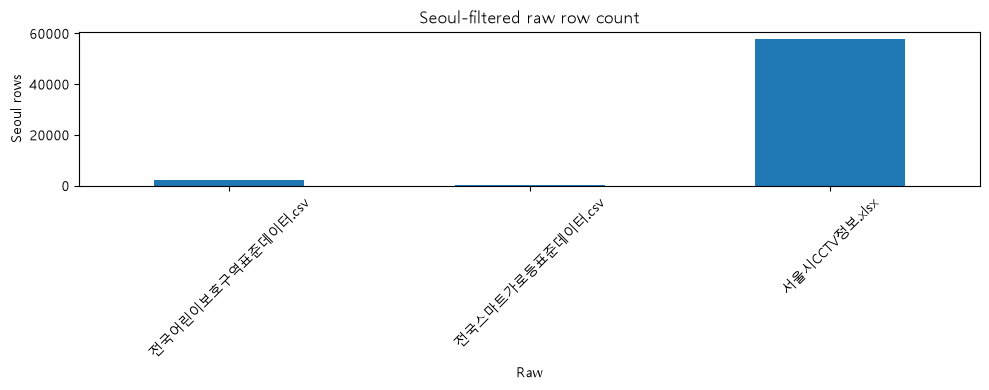

In [50]:
ax = seoul_file_quality.plot.bar(x="raw_name", y="seoul_rows", legend=False, figsize=(10, 4), title="Seoul-filtered raw row count")
ax.set_xlabel("Raw")
ax.set_ylabel("Seoul rows")
ax.tick_params(axis="x", labelrotation=45)
fig = ax.get_figure()
fig.tight_layout()
if "ensure_figure_dir" not in globals():
    from pathlib import Path
    def ensure_figure_dir():
        root = globals().get("ROOT", Path.cwd())
        if root.name == "raw":
            root = root.parents[1]
        elif root.name == "analysis":
            root = root.parent
        figure_dir = root / "analysis" / "figures" / "raw"
        figure_dir.mkdir(parents=True, exist_ok=True)
        return figure_dir
figure_dir = ensure_figure_dir()
fig.savefig(figure_dir / "raw_file_row_count.png", dpi=160, bbox_inches="tight")


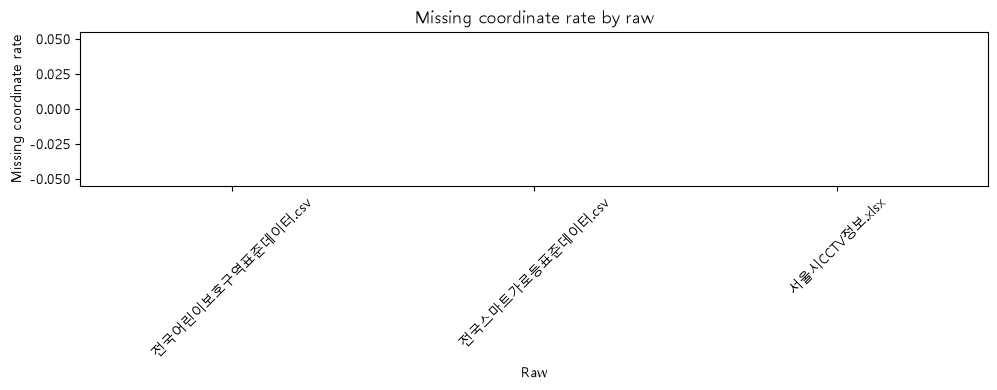

In [51]:
ax = seoul_file_quality.plot.bar(x="raw_name", y="missing_coord_rate", legend=False, figsize=(10, 4), title="Missing coordinate rate by raw")
ax.set_xlabel("Raw")
ax.set_ylabel("Missing coordinate rate")
ax.tick_params(axis="x", labelrotation=45)
fig = ax.get_figure()
fig.tight_layout()
if "ensure_figure_dir" not in globals():
    from pathlib import Path
    def ensure_figure_dir():
        root = globals().get("ROOT", Path.cwd())
        if root.name == "raw":
            root = root.parents[1]
        elif root.name == "analysis":
            root = root.parent
        figure_dir = root / "analysis" / "figures" / "raw"
        figure_dir.mkdir(parents=True, exist_ok=True)
        return figure_dir
figure_dir = ensure_figure_dir()
fig.savefig(figure_dir / "raw_file_missing_coord_rate.png", dpi=160, bbox_inches="tight")


## 3. 자치구별 raw 분포

자치구 컬럼이 직접 있거나 주소에서 `OO구`를 추출할 수 있는 데이터는 구별 쏠림을 확인한다.

In [52]:
gu_distribution_rows = []
gu_unknown_rows = []

for cfg in file_raw_configs:
    df = seoul_file_raw_frames[cfg["name"]].copy()
    candidate_cols = []
    for col in [cfg.get("gu_col")]:
        if col and col not in candidate_cols:
            candidate_cols.append(col)
    for col in cfg.get("address_cols", []) + cfg.get("city_cols", []):
        if col and col not in candidate_cols:
            candidate_cols.append(col)

    df["gu"] = df.apply(lambda row: extract_seoul_gu_from_row(row, candidate_cols), axis=1)
    unknown_count = int(df["gu"].isna().sum())
    gu_unknown_rows.append({
        "raw_name": cfg["name"],
        "seoul_filtered_rows": len(df),
        "unknown_or_non_seoul_gu_rows": unknown_count,
    })

    counts = df.loc[df["gu"].notna(), "gu"].value_counts().reset_index()
    counts.columns = ["gu", "count"]
    counts["raw_name"] = cfg["name"]
    gu_distribution_rows.append(counts)

gu_distribution = pd.concat(gu_distribution_rows, ignore_index=True) if gu_distribution_rows else pd.DataFrame(columns=["gu", "count", "raw_name"])
gu_unknown_summary = pd.DataFrame(gu_unknown_rows)

display(gu_distribution.head(20))
display(gu_unknown_summary)


,gu,count,raw_name
0,노원구,115,전국어린이보호구역표준데이터.csv
1,송파구,98,전국어린이보호구역표준데이터.csv
2,성북구,94,전국어린이보호구역표준데이터.csv
3,강남구,92,전국어린이보호구역표준데이터.csv
4,서초구,92,전국어린이보호구역표준데이터.csv
5,강서구,88,전국어린이보호구역표준데이터.csv
6,강동구,84,전국어린이보호구역표준데이터.csv
7,동대문구,76,전국어린이보호구역표준데이터.csv
8,도봉구,69,전국어린이보호구역표준데이터.csv
9,관악구,68,전국어린이보호구역표준데이터.csv


,raw_name,seoul_filtered_rows,unknown_or_non_seoul_gu_rows
0,전국어린이보호구역표준데이터.csv,2199,587
1,전국스마트가로등표준데이터.csv,357,40
2,서울시CCTV정보.xlsx,57757,14496


raw_name,서울시CCTV정보.xlsx,전국스마트가로등표준데이터.csv,전국어린이보호구역표준데이터.csv
gu,,,
강남구,2551.0,0.0,92.0
강동구,1.0,0.0,84.0
강북구,4360.0,0.0,35.0
강서구,1964.0,49.0,88.0
관악구,510.0,0.0,68.0
광진구,0.0,178.0,66.0
구로구,2132.0,42.0,56.0
금천구,0.0,0.0,40.0
노원구,3111.0,0.0,115.0


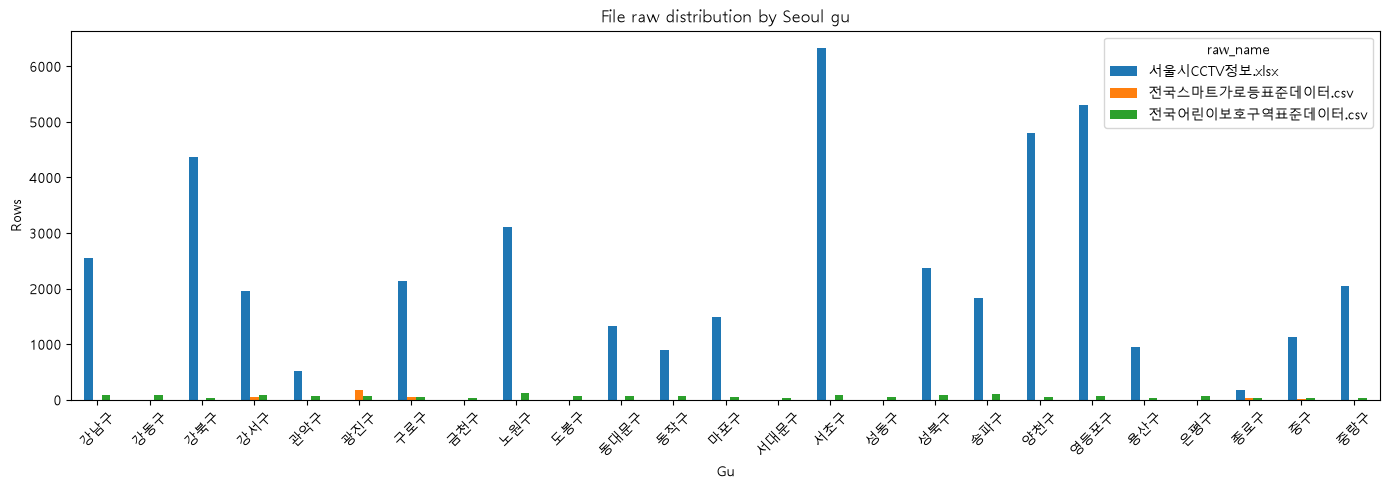

In [53]:
gu_pivot = gu_distribution.pivot_table(index="gu", columns="raw_name", values="count", fill_value=0)
gu_pivot = gu_pivot.sort_index()
display(gu_pivot)

ax = gu_pivot.plot.bar(figsize=(14, 5), title="File raw distribution by Seoul gu")
ax.set_xlabel("Gu")
ax.set_ylabel("Rows")
ax.tick_params(axis="x", labelrotation=45)
fig = ax.get_figure()
fig.tight_layout()
if "ensure_figure_dir" not in globals():
    from pathlib import Path
    def ensure_figure_dir():
        root = globals().get("ROOT", Path.cwd())
        if root.name == "raw":
            root = root.parents[1]
        elif root.name == "analysis":
            root = root.parent
        figure_dir = root / "analysis" / "figures" / "raw"
        figure_dir.mkdir(parents=True, exist_ok=True)
        return figure_dir
figure_dir = ensure_figure_dir()
fig.savefig(figure_dir / "raw_gu_distribution.png", dpi=160, bbox_inches="tight")


## 4. 도보 네트워크 기본 통계

 도보 네트워크는 별도로 본다.

- 자치구별 node 수
- 자치구별 edge 수
- 자치구별 edge 총 길이
- edge 길이 분포
- 교량/터널/육교/횡단보도/공원녹지/건물내 컬럼 분포

면적 대비 밀도는 서울/자치구 경계 데이터가 준비되면 `nodes / km²`, `edge_length_km / km²`로 확장한다.

In [54]:
walk_path = RAW_DIR / "서울시 자치구별 도보 네트워크 공간정보.csv"
walk_df = read_csv_korean(walk_path)

walk_nodes = walk_df[walk_df["노드링크 유형"] == "NODE"].copy()
walk_edges = walk_df[walk_df["노드링크 유형"] == "LINK"].copy()

walk_summary = pd.DataFrame([
    {"metric": "rows", "value": len(walk_df)},
    {"metric": "nodes", "value": len(walk_nodes)},
    {"metric": "edges", "value": len(walk_edges)},
    {"metric": "edge_length_km", "value": round(pd.to_numeric(walk_edges["링크 길이"], errors="coerce").sum() / 1000, 2)},
])
walk_summary

,metric,value
0,rows,491082.00
1,nodes,212066.00
2,edges,279016.00
3,edge_length_km,12807.23


In [55]:
walk_gu_summary = (
    walk_df.assign(edge_length_m=pd.to_numeric(walk_df.get("링크 길이"), errors="coerce"))
    .groupby("시군구명")
    .agg(
        node_count=("노드링크 유형", lambda s: (s == "NODE").sum()),
        edge_count=("노드링크 유형", lambda s: (s == "LINK").sum()),
        edge_length_km=("edge_length_m", lambda s: round(s.sum(skipna=True) / 1000, 2)),
    )
    .reset_index()
    .sort_values("edge_length_km", ascending=False)
)
walk_gu_summary.head(30)

,시군구명,node_count,edge_count,edge_length_km
0,강남구,12267,16867,888.16
17,송파구,9143,12636,739.06
14,서초구,8039,10911,666.30
16,성북구,12009,15154,607.40
8,노원구,10673,13553,606.09
3,강서구,7947,10856,586.41
19,영등포구,9674,13126,576.30
12,마포구,8662,11657,563.14
1,강동구,8217,11057,544.98
18,양천구,8145,11111,524.37


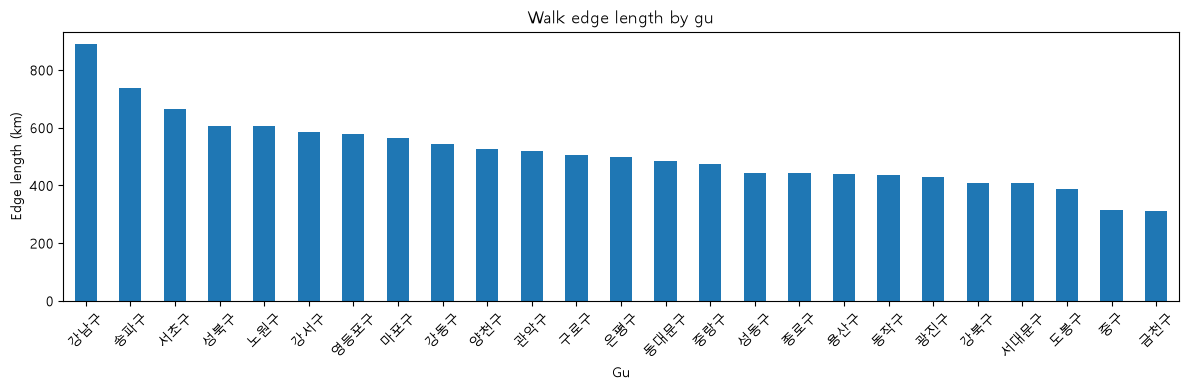

In [56]:
ax = walk_gu_summary.plot.bar(x="시군구명", y="edge_length_km", legend=False, figsize=(12, 4), title="Walk edge length by gu")
ax.set_xlabel("Gu")
ax.set_ylabel("Edge length (km)")
ax.tick_params(axis="x", labelrotation=45)
fig = ax.get_figure()
fig.tight_layout()
if "ensure_figure_dir" not in globals():
    from pathlib import Path
    def ensure_figure_dir():
        root = globals().get("ROOT", Path.cwd())
        if root.name == "raw":
            root = root.parents[1]
        elif root.name == "analysis":
            root = root.parent
        figure_dir = root / "analysis" / "figures" / "raw"
        figure_dir.mkdir(parents=True, exist_ok=True)
        return figure_dir
figure_dir = ensure_figure_dir()
fig.savefig(figure_dir / "walk_gu_edge_length.png", dpi=160, bbox_inches="tight")


In [57]:
edge_lengths = pd.to_numeric(walk_edges["링크 길이"], errors="coerce").dropna()
edge_lengths.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame("edge_length_m")

,edge_length_m
count,279016.000000
mean,45.901417
std,55.968715
min,0.098000
1%,5.009150
5%,8.382000
50%,31.973000
95%,123.238250
99%,229.358600
max,5376.280000


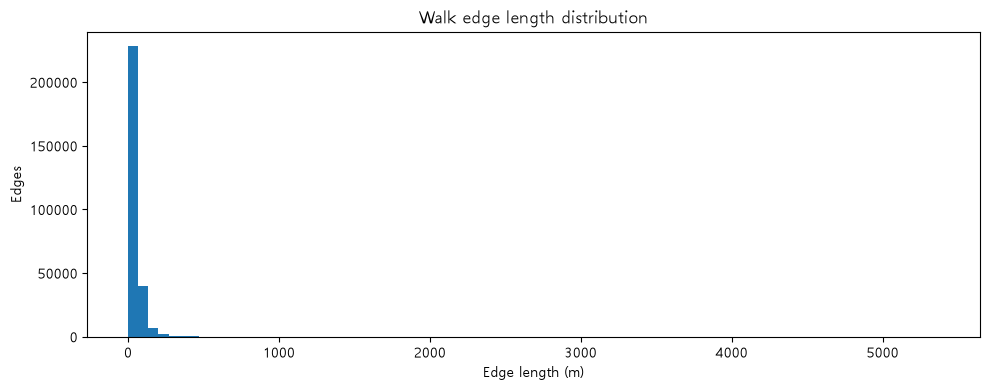

In [58]:
ax = edge_lengths.plot.hist(bins=80, figsize=(10, 4), title="Walk edge length distribution")
ax.set_xlabel("Edge length (m)")
ax.set_ylabel("Edges")
fig = ax.get_figure()
fig.tight_layout()
if "ensure_figure_dir" not in globals():
    from pathlib import Path
    def ensure_figure_dir():
        root = globals().get("ROOT", Path.cwd())
        if root.name == "raw":
            root = root.parents[1]
        elif root.name == "analysis":
            root = root.parent
        figure_dir = root / "analysis" / "figures" / "raw"
        figure_dir.mkdir(parents=True, exist_ok=True)
        return figure_dir
figure_dir = ensure_figure_dir()
fig.savefig(figure_dir / "walk_edge_length_distribution.png", dpi=160, bbox_inches="tight")


In [59]:
special_cols = ["고가도로", "지하철네트워크", "교량", "터널", "육교", "횡단보도", "공원,녹지", "건물내"]
special_summary = []

for col in special_cols:
    if col in walk_edges.columns:
        special_summary.append({
            "column": col,
            "non_null_rows": int(walk_edges[col].notna().sum()),
            "value_counts": walk_edges[col].value_counts(dropna=False).head(5).to_dict(),
        })

pd.DataFrame(special_summary)

,column,non_null_rows,value_counts
0,고가도로,279016,"{0.0: 276185, 1.0: 2831}"
1,지하철네트워크,279016,"{0.0: 278842, 1.0: 174}"
2,교량,279016,"{0.0: 278440, 1.0: 576}"
3,터널,279016,"{0.0: 278835, 1.0: 181}"
4,육교,279016,"{0: 277557, 1: 1459}"
5,횡단보도,279016,"{0: 271118, 1: 7898}"
6,"공원,녹지",279016,"{0.0: 277854, 1.0: 1162}"
7,건물내,279016,"{0.0: 267455, 1.0: 11561}"


## 5. API/OSM 데이터 검증 기준

API/OSM 데이터는 파일처럼 항상 같은 시점의 원본이 아니다. 따라서 대시보드에 다음 검증 메타데이터를 함께 둔다.

| raw | endpoint/source | 수집 컬럼 | 정제 후 컬럼 | 검증 기준 |
|---|---|---|---|---|
| 어린이놀이시설 API | `apis.data.go.kr/1741000/pfc3/getPfctInfo3` | `pfctNm`, `ronaAddr`, `latCrtsVl`, `lotCrtsVl` | `name`, `address`, `lat`, `lon` | fetched_at, 좌표 결측, 서울 주소 여부, 자치구 분포 |
| 보행자 사고 다발지점 API | `opendata.koroad.or.kr/data/rest/frequentzone/pedstrians` | `spot_nm`, `sido_sgg_nm`, `geom_json` | `name`, `address`, `lat`, `lon` | fetched_at, 구별 분포, 중복 좌표 |
| TourAPI | `apis.data.go.kr/B551011/KorService2/areaBasedList2` | `title`, `addr1`, `mapx`, `mapy` | `name`, `address`, `lon`, `lat` | fetched_at, 좌표 결측, 자치구 분포 |
| 실외운동기구 API | `api.data.go.kr/openapi/tn_pubr_public_outdoor_exercise_eqmt_api` | `instlPlcNm`, `lctnLotnoAddr`, `lat`, `lot`, `ctpvNm` | `name`, `address`, `lat`, `lon` | fetched_at, 서울 필터, 자치구 분포 |
| OSM 녹지 | `osmnx.features_from_place("Seoul, South Korea")` | geometry, natural, landuse, leisure | `green_type`, `green_weight`, geometry | fetched_at, 태그별 개수, geometry 유효성, 서울 경계 밖 여부 |

주의: OSM은 공식 행정 데이터가 아니라 커뮤니티 기반 지도 데이터이므로 최신성/신뢰성 검증이 필요하다.

### 5-1. DB 적재 상태 실제 조회

이 섹션은 외부 API를 다시 호출하지 않는다. `.env` 기준 PostgreSQL 연결이 가능하면 이미 적재된 raw table을 조회해 `query_key`, row 수, geometry 수, `fetched_at`을 확인한다. DB 연결이 불가능한 경우에도 노트북 실행은 중단되지 않고 상태 메시지를 반환한다.

In [38]:
import os
from urllib.parse import quote_plus

try:
    from dotenv import load_dotenv
    from sqlalchemy import create_engine, text
except ImportError as exc:
    load_dotenv = None
    create_engine = None
    text = None
    DB_IMPORT_ERROR = exc
else:
    DB_IMPORT_ERROR = None

if load_dotenv is not None:
    load_dotenv(ROOT / ".env", encoding="utf-8")

ALLOWED_RAW_TABLES = {"csv_raw", "public_raw", "osm_raw", "kakao_raw"}

def build_db_url():
    required = ["POSTGRES_USER", "POSTGRES_PASSWORD", "POSTGRES_DB"]
    missing = [key for key in required if not os.getenv(key)]
    if missing:
        return None, f"missing env: {', '.join(missing)}"
    user = quote_plus(os.getenv("POSTGRES_USER"))
    password = quote_plus(os.getenv("POSTGRES_PASSWORD"))
    host = os.getenv("POSTGRES_HOST", "localhost")
    port = os.getenv("POSTGRES_PORT", "5434")
    db = os.getenv("POSTGRES_DB")
    return f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{db}?client_encoding=utf8", None

def get_engine_or_status():
    if DB_IMPORT_ERROR is not None:
        return None, f"DB import failed: {DB_IMPORT_ERROR}"
    db_url, reason = build_db_url()
    if reason:
        return None, reason
    try:
        engine = create_engine(db_url, pool_pre_ping=True)
        with engine.connect() as conn:
            conn.execute(text("SELECT 1"))
        return engine, None
    except Exception as exc:
        return None, f"DB unavailable: {exc}"

def table_exists(engine, table_name):
    query = text("""
        SELECT EXISTS (
            SELECT 1
            FROM information_schema.tables
            WHERE table_schema = 'public'
              AND table_name = :table_name
        ) AS exists
    """)
    return bool(pd.read_sql(query, engine, params={"table_name": table_name}).iloc[0, 0])

def raw_table_status(table_name):
    if table_name not in ALLOWED_RAW_TABLES:
        raise ValueError(f"unexpected table: {table_name}")
    engine, status = get_engine_or_status()
    if engine is None:
        return pd.DataFrame([{"raw_table": table_name, "query_key": None, "row_count": None, "geom_count": None, "missing_geom_count": None, "first_fetched_at": None, "last_fetched_at": None, "status": status}])
    try:
        if not table_exists(engine, table_name):
            return pd.DataFrame([{"raw_table": table_name, "query_key": None, "row_count": None, "geom_count": None, "missing_geom_count": None, "first_fetched_at": None, "last_fetched_at": None, "status": "table not found"}])
        query = text(f"""
            SELECT query_key, COUNT(*) AS row_count, COUNT(geom) AS geom_count,
                   COUNT(*) FILTER (WHERE geom IS NULL) AS missing_geom_count,
                   MIN(fetched_at) AS first_fetched_at, MAX(fetched_at) AS last_fetched_at,
                   'ok' AS status
            FROM {table_name}
            GROUP BY query_key
            ORDER BY query_key
        """)
        result = pd.read_sql(query, engine)
        result.insert(0, "raw_table", table_name)
        return result
    except Exception as exc:
        return pd.DataFrame([{"raw_table": table_name, "query_key": None, "row_count": None, "geom_count": None, "missing_geom_count": None, "first_fetched_at": None, "last_fetched_at": None, "status": f"query failed: {exc}"}])


In [39]:
raw_db_status = pd.concat(
    [raw_table_status(table_name) for table_name in ["public_raw", "osm_raw", "csv_raw"]],
    ignore_index=True,
)
raw_db_status


,raw_table,query_key,row_count,geom_count,missing_geom_count,first_fetched_at,last_fetched_at,status
0,public_raw,type=landmark,660,660,0,2026-06-24 09:43:00.395244,2026-06-24 09:43:00.395244,ok
1,public_raw,type=play_facility,7066,7066,0,2026-06-24 09:42:45.448586,2026-06-24 09:42:45.448586,ok
2,osm_raw,landuse=allotments,10,10,0,2026-06-24 06:18:57.234190,2026-06-24 06:18:57.234190,ok
3,osm_raw,landuse=farmland,111,111,0,2026-06-24 06:18:49.249649,2026-06-24 06:18:49.249649,ok
4,osm_raw,landuse=forest,394,394,0,2026-06-24 06:14:58.505555,2026-06-24 06:14:58.505555,ok
5,osm_raw,landuse=grass,1714,1714,0,2026-06-24 06:17:10.736496,2026-06-24 06:17:10.736496,ok
6,osm_raw,landuse=meadow,46,46,0,2026-06-24 06:18:41.113534,2026-06-24 06:18:41.113534,ok
7,osm_raw,leisure=garden,976,976,0,2026-06-24 06:16:59.352338,2026-06-24 06:16:59.352338,ok
8,osm_raw,leisure=park,2230,2230,0,2026-06-24 06:15:26.685458,2026-06-24 06:15:26.685458,ok
9,osm_raw,natural=scrub,70,70,0,2026-06-24 06:14:49.811354,2026-06-24 06:14:49.811354,ok


### 5-2. API/OSM 예상 query_key 확인

이 표는 source code에 정의된 API/OSM 수집용 `query_key`와 실제 `public_raw`, `osm_raw`에 적재된 `query_key`를 비교한다. `row_count`가 비어 있거나 DB 연결 불가 상태가 표시되면, 현재 실행 환경에서는 DB 적재 내용을 검증하지 못한 것으로 본다.

In [40]:
expected_api_osm_keys = pd.DataFrame([
    {"raw": "play_facility API", "raw_table": "public_raw", "expected_query_key": "type=play_facility"},
    {"raw": "TourAPI landmark/culture API", "raw_table": "public_raw", "expected_query_key": "type=landmark"},
    {"raw": "pedestrian accident zone API", "raw_table": "public_raw", "expected_query_key": "type=accident_zone"},
    {"raw": "outdoor exercise equipment API", "raw_table": "public_raw", "expected_query_key": "type=outdoor_exercise"},
    {"raw": "OSM natural=wood", "raw_table": "osm_raw", "expected_query_key": "natural=wood"},
    {"raw": "OSM natural=scrub", "raw_table": "osm_raw", "expected_query_key": "natural=scrub"},
    {"raw": "OSM landuse=forest", "raw_table": "osm_raw", "expected_query_key": "landuse=forest"},
    {"raw": "OSM leisure=park", "raw_table": "osm_raw", "expected_query_key": "leisure=park"},
    {"raw": "OSM leisure=garden", "raw_table": "osm_raw", "expected_query_key": "leisure=garden"},
    {"raw": "OSM landuse=grass", "raw_table": "osm_raw", "expected_query_key": "landuse=grass"},
    {"raw": "OSM landuse=meadow", "raw_table": "osm_raw", "expected_query_key": "landuse=meadow"},
    {"raw": "OSM landuse=farmland", "raw_table": "osm_raw", "expected_query_key": "landuse=farmland"},
    {"raw": "OSM landuse=allotments", "raw_table": "osm_raw", "expected_query_key": "landuse=allotments"},
])

api_osm_key_check = expected_api_osm_keys.merge(
    raw_db_status,
    left_on=["raw_table", "expected_query_key"],
    right_on=["raw_table", "query_key"],
    how="left",
)
api_osm_key_check["loaded"] = api_osm_key_check["row_count"].notna()
api_osm_key_check[["raw", "raw_table", "expected_query_key", "loaded", "row_count", "missing_geom_count", "first_fetched_at", "last_fetched_at", "status"]]


,raw,raw_table,expected_query_key,loaded,row_count,missing_geom_count,first_fetched_at,last_fetched_at,status
0,play_facility API,public_raw,type=play_facility,True,7066.0,0.0,2026-06-24 09:42:45.448586,2026-06-24 09:42:45.448586,ok
1,TourAPI landmark/culture API,public_raw,type=landmark,True,660.0,0.0,2026-06-24 09:43:00.395244,2026-06-24 09:43:00.395244,ok
2,pedestrian accident zone API,public_raw,type=accident_zone,False,NaN,NaN,NaT,NaT,NaN
3,outdoor exercise equipment API,public_raw,type=outdoor_exercise,False,NaN,NaN,NaT,NaT,NaN
4,OSM natural=wood,osm_raw,natural=wood,True,1050.0,0.0,2026-06-24 06:14:41.803774,2026-06-24 06:14:41.803774,ok
5,OSM natural=scrub,osm_raw,natural=scrub,True,70.0,0.0,2026-06-24 06:14:49.811354,2026-06-24 06:14:49.811354,ok
6,OSM landuse=forest,osm_raw,landuse=forest,True,394.0,0.0,2026-06-24 06:14:58.505555,2026-06-24 06:14:58.505555,ok
7,OSM leisure=park,osm_raw,leisure=park,True,2230.0,0.0,2026-06-24 06:15:26.685458,2026-06-24 06:15:26.685458,ok
8,OSM leisure=garden,osm_raw,leisure=garden,True,976.0,0.0,2026-06-24 06:16:59.352338,2026-06-24 06:16:59.352338,ok
9,OSM landuse=grass,osm_raw,landuse=grass,True,1714.0,0.0,2026-06-24 06:17:10.736496,2026-06-24 06:17:10.736496,ok


### 5-3. 좌표 및 geometry 품질 확인

DB 연결이 가능하면 `public_raw`는 서울 bbox 안에 포함되는 point row 비율을 확인하고, `osm_raw`는 유효하지 않은 geometry 여부와 서울 bbox 교차 여부를 확인한다. bbox는 1차 필터일 뿐이며, 최종적인 서울 포함 여부는 행정구역 boundary polygon과 spatial join을 적용해 판단해야 한다.

In [41]:
def public_raw_spatial_quality():
    engine, status = get_engine_or_status()
    if engine is None:
        return pd.DataFrame([{"raw_table": "public_raw", "status": status}])
    try:
        query = text("""
            SELECT query_key, COUNT(*) AS row_count,
                   COUNT(*) FILTER (WHERE ST_Y(geom) BETWEEN 37.40 AND 37.72 AND ST_X(geom) BETWEEN 126.75 AND 127.22) AS bbox_seoul_rows,
                   COUNT(*) FILTER (WHERE geom IS NULL) AS missing_geom_count,
                   COUNT(*) - COUNT(DISTINCT ST_AsText(geom)) AS duplicate_geom_count
            FROM public_raw
            GROUP BY query_key
            ORDER BY query_key
        """)
        result = pd.read_sql(query, engine)
        result.insert(0, "raw_table", "public_raw")
        result["bbox_seoul_rate"] = result["bbox_seoul_rows"] / result["row_count"]
        result["status"] = "ok"
        return result
    except Exception as exc:
        return pd.DataFrame([{"raw_table": "public_raw", "status": f"query failed: {exc}"}])

def osm_raw_spatial_quality():
    engine, status = get_engine_or_status()
    if engine is None:
        return pd.DataFrame([{"raw_table": "osm_raw", "status": status}])
    try:
        query = text("""
            SELECT query_key, COUNT(*) AS row_count,
                   COUNT(*) FILTER (WHERE NOT ST_IsValid(geom)) AS invalid_geom_count,
                   COUNT(*) FILTER (WHERE ST_Intersects(geom, ST_MakeEnvelope(126.75, 37.40, 127.22, 37.72, 4326))) AS bbox_intersect_rows
            FROM osm_raw
            GROUP BY query_key
            ORDER BY query_key
        """)
        result = pd.read_sql(query, engine)
        result.insert(0, "raw_table", "osm_raw")
        result["bbox_intersect_rate"] = result["bbox_intersect_rows"] / result["row_count"]
        result["status"] = "ok"
        return result
    except Exception as exc:
        return pd.DataFrame([{"raw_table": "osm_raw", "status": f"query failed: {exc}"}])

public_spatial_quality = public_raw_spatial_quality()
osm_spatial_quality = osm_raw_spatial_quality()

display(public_spatial_quality)
display(osm_spatial_quality)


,raw_table,query_key,row_count,bbox_seoul_rows,missing_geom_count,duplicate_geom_count,bbox_seoul_rate,status
0,public_raw,type=landmark,660,659,0,0,0.998485,ok
1,public_raw,type=play_facility,7066,7020,0,7,0.993490,ok


,raw_table,query_key,row_count,invalid_geom_count,bbox_intersect_rows,bbox_intersect_rate,status
0,osm_raw,landuse=allotments,10,0,10,1.0,ok
1,osm_raw,landuse=farmland,111,0,111,1.0,ok
2,osm_raw,landuse=forest,394,0,394,1.0,ok
3,osm_raw,landuse=grass,1714,0,1714,1.0,ok
4,osm_raw,landuse=meadow,46,0,46,1.0,ok
5,osm_raw,leisure=garden,976,0,976,1.0,ok
6,osm_raw,leisure=park,2230,0,2230,1.0,ok
7,osm_raw,natural=scrub,70,0,70,1.0,ok
8,osm_raw,natural=wood,1050,0,1050,1.0,ok


### 5-4. raw row의 layer table 실제 참조 여부 확인

이 섹션은 raw table에 단순히 적재만 된 row와 FK 컬럼을 통해 layer table에 실제로 연결된 raw row를 구분한다.

In [42]:
def layer_raw_reference_check():
    engine, status = get_engine_or_status()
    if engine is None:
        return pd.DataFrame([{"check_name": "layer raw reference", "status": status}])
    checks = [
        ("child_layer.csv_raw_id", "child_layer", "csv_raw_id"),
        ("child_layer.public_raw_id", "child_layer", "public_raw_id"),
        ("safety_layer.csv_raw_id", "safety_layer", "csv_raw_id"),
        ("safety_layer.public_raw_id", "safety_layer", "public_raw_id"),
        ("nature_layer.osm_raw_id", "nature_layer", "osm_raw_id"),
        ("running_layer.csv_raw_id", "running_layer", "csv_raw_id"),
    ]
    rows = []
    with engine.connect() as conn:
        for check_name, table_name, fk_col in checks:
            try:
                if not table_exists(engine, table_name):
                    rows.append({"check_name": check_name, "referenced_rows": None, "status": "table not found"})
                    continue
                query = text(f"SELECT COUNT(*) AS referenced_rows FROM {table_name} WHERE {fk_col} IS NOT NULL")
                referenced_rows = pd.read_sql(query, conn).iloc[0, 0]
                rows.append({"check_name": check_name, "referenced_rows": referenced_rows, "status": "ok"})
            except Exception as exc:
                rows.append({"check_name": check_name, "referenced_rows": None, "status": f"query failed: {exc}"})
    return pd.DataFrame(rows)

layer_reference_status = layer_raw_reference_check()
layer_reference_status


,check_name,referenced_rows,status
0,child_layer.csv_raw_id,1184.0,ok
1,child_layer.public_raw_id,7066.0,ok
2,safety_layer.csv_raw_id,45016.0,ok
3,safety_layer.public_raw_id,NaN,"query failed: (psycopg2.errors.UndefinedColumn) column ""public_raw_id"" does not exist\nLINE 1: ...UNT(*) AS referenc..."
4,nature_layer.osm_raw_id,NaN,"query failed: (psycopg2.errors.InFailedSqlTransaction) current transaction is aborted, commands ignored until end of..."
5,running_layer.csv_raw_id,NaN,"query failed: (psycopg2.errors.InFailedSqlTransaction) current transaction is aborted, commands ignored until end of..."


## 6. 다음 단계

- DB 연결이 가능하면 5번 섹션을 실행해 `public_raw`, `osm_raw`, `csv_raw`의 `query_key`, `fetched_at`, row 수를 확인한다.
- DB 연결이 불가능한 경우에는 5번 섹션을 실행 가능한 검증 방법과 source code 기준 예상 `query_key` 목록으로 남긴다.
- 서울/자치구 경계 polygon이 준비되면 모든 point/polygon raw 데이터에 spatial join을 적용한다.
- `count / km²`, `edge_length_km / km²` 같은 면적 대비 밀도 지표를 추가한다.
- 하천/수계 polygon과 walk edge를 overlay해 하천 주변 도보 네트워크가 반영되는지 확인한다.

### OSM 데이터 신뢰성 검증 방법

OSM은 공식 행정 데이터가 아니라 커뮤니티 기반 지도 데이터이므로 허위/오류/누락 가능성이 있다. 따라서 본 분석에서는 다음 기준으로 신뢰성을 점검한다.

- `osm_raw.fetched_at` 기준 수집 시점 확인
- `query_key`별 row 수 확인
- geometry null 여부 확인
- `ST_IsValid(geom)` 기준 geometry 유효성 확인
- 서울 bbox 또는 서울 행정구역 boundary와 교차 여부 확인
- 지도 시각화를 통해 서울 내 공원/녹지 위치와 일치하는지 확인
- 추후 서울시 공식 공원/녹지 데이터와 자치구별 분포 비교